In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Add the 'src' directory to the Python path so we can import our modules
sys.path.append(os.path.abspath('../src'))

# Import our custom data loader
from data_loader import get_sp500_tickers, download_price_data, clean_price_data

# Make plots look professional
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [6]:
# For the MVP, let's use a highly liquid subset of the S&P 500 to keep downloads fast.
# In a real scenario, you'd use get_sp500_tickers()
mvp_universe = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'BRK-B', 'JPM', 'JNJ',
    'V', 'PG', 'XOM', 'HD', 'CVX', 'MA', 'BAC', 'ABBV', 'PFE', 'AVGO', 
    'COST', 'DIS', 'KO', 'PEP', 'CSCO', 'WMT', 'TMO', 'MCD', 'ABT', 'CRM'
]

# Set a 5-year backtest window
START_DATE = '2021-01-01'
END_DATE = '2026-12-31'

# Download the data
prices_raw, volumes_raw = download_price_data(mvp_universe, START_DATE, END_DATE)

print(f"Raw Prices Shape: {prices_raw.shape}")
prices_raw.tail()

2026-03-27 12:15:22,432 - INFO - Downloading data for 30 tickers from 2021-01-01 to 2026-12-31...


Raw Prices Shape: (1313, 30)


Ticker,AAPL,ABBV,ABT,AMZN,AVGO,BAC,BRK-B,COST,CRM,CSCO,...,MSFT,NVDA,PEP,PFE,PG,TMO,TSLA,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2026-03-20,247.990005,205.070007,105.459999,205.369995,309.860016,47.160000,480.940002,972.330017,195.380005,77.650002,...,381.869995,172.699997,150.039993,26.969999,144.279999,474.390015,367.959991,301.619995,119.019997,159.669998
2026-03-23,251.490005,204.929993,104.849998,210.139999,322.510010,47.520000,479.980011,965.729980,195.179993,78.820000,...,383.000000,175.639999,150.880005,26.770000,143.990005,478.119995,380.850006,304.440002,120.720001,161.130005
2026-03-24,251.639999,205.199997,104.059998,207.240005,318.290009,48.139999,479.329987,973.820007,183.020004,80.860001,...,372.739990,175.199997,150.589996,26.959999,143.160004,490.290009,383.029999,303.760010,122.050003,165.380005
2026-03-25,252.619995,207.179993,104.830002,211.710007,318.809998,48.750000,476.190002,974.859985,181.960007,81.830002,...,371.040009,178.679993,151.729996,27.280001,143.919998,490.769989,385.950012,304.910004,123.059998,163.259995
2026-03-26,252.889999,211.119995,104.570000,207.539993,309.415009,48.240002,475.269989,979.650024,185.639999,82.160004,...,365.970001,171.240005,150.830002,27.570000,142.419998,488.850006,372.109985,305.529999,122.180000,165.429993


In [7]:
# Clean the prices (drops highly illiquid names, fills gaps)
prices = clean_price_data(prices_raw)

# Calculate daily returns
returns = prices.pct_change(fill_method=None).dropna()

print(f"Returns Shape: {returns.shape}")
returns.head()

2026-03-27 12:15:30,596 - INFO - Shape before cleaning: (1313, 30)
2026-03-27 12:15:30,676 - INFO - Shape after cleaning: (1313, 30) (0 dropped)


Returns Shape: (1312, 30)


Ticker,AAPL,ABBV,ABT,AMZN,AVGO,BAC,BRK-B,COST,CRM,CSCO,...,MSFT,NVDA,PEP,PFE,PG,TMO,TSLA,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-05,0.012364,0.010340,0.012373,0.010004,0.006773,0.007659,-0.004290,-0.011601,0.005492,0.000455,...,0.000964,0.022210,0.002981,0.010323,0.006385,0.012505,0.007317,-0.014925,-0.005323,0.048193
2021-01-06,-0.033662,-0.008639,-0.002082,-0.024897,-0.006167,0.062459,0.012309,-0.015223,-0.024242,0.009550,...,-0.025929,-0.058953,-0.012233,-0.008604,0.010526,0.015678,0.028390,-0.008811,0.006244,0.025517
2021-01-07,0.034123,0.010703,0.009707,0.007577,0.042143,0.022084,0.011335,-0.005675,0.008466,0.012613,...,0.028457,0.057831,-0.003218,0.005154,-0.009346,0.031162,0.079447,0.005597,-0.000068,0.007846
2021-01-08,0.008631,0.005248,0.002785,0.006496,0.005074,-0.010043,0.004938,0.005490,0.018626,0.002224,...,0.006093,-0.005040,0.012002,0.001889,-0.000432,0.023924,0.078403,0.007670,-0.000136,0.011121
2021-01-11,-0.023249,0.016314,-0.006899,-0.021519,0.000269,0.016600,-0.002564,-0.016030,-0.017069,0.006658,...,-0.009699,0.025966,-0.014496,0.017236,-0.006773,0.002049,-0.078214,-0.011882,0.004501,0.030357


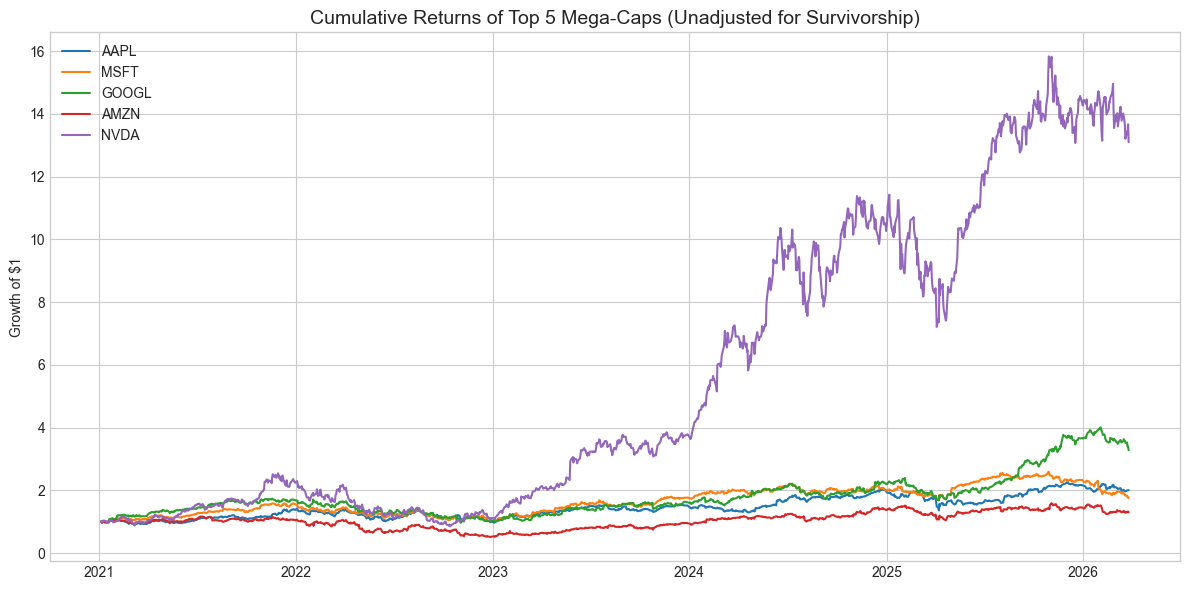

In [8]:
# Let's plot the cumulative returns of a few top names to ensure data sanity
cumulative_returns = (1 + returns).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))
top_5 = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA']

for ticker in top_5:
    if ticker in cumulative_returns.columns:
        ax.plot(cumulative_returns.index, cumulative_returns[ticker], label=ticker)

ax.set_title("Cumulative Returns of Top 5 Mega-Caps (Unadjusted for Survivorship)", fontsize=14)
ax.set_ylabel("Growth of $1")
ax.legend()
plt.tight_layout()
plt.show()